# CDR-Selective Resampling for Boltz-2 — Colab runner

Boltz-2 predicts one antibody–antigen pose per seed, and reseeding barely moves the CDR
loops that make almost the whole paratope — so a binder campaign gets no alternatives to
choose among. This patches its diffusion sampler so that noise, re-noising, and a
differentiable epitope potential apply to **CDR atoms only**, leaving the framework and the
docked pose intact, with no retraining. Three nanobody–antigen complexes, measured against
unmodified Boltz-2.

| § | Step | Time (A100) |
|---|---|---|
| 1–3 | install, clone, fetch targets, choose which loops to resample | ~5 min (3 GB weights, once) |
| 4 | **forward and backward pass** through the guidance potential — CPU | seconds |
| 5 | **Stage 0** — stock Boltz-2 dock: the baseline, and the poses the arms build on | ~4 min/target |
| 6 | **Arm A** — re-predict with the CDRs deleted from a template | ~8 min/target |
| 7 | **Arm B** — CDR-selective diffusion resampling, three sub-arms | ~12 min/target |
| 8 | accuracy, diversity, and which score picks the best structure — CPU | ~1 min |
| 9–12 | ensemble figures, summary panels, download, copy to Drive | ~1 min |

**GPU (A100 or L4)** — *Runtime → Change runtime type → GPU*; only §5–7 need one.
`scripts/06_synthetic_ensemble.py` exercises the whole analysis path without one.

## 1 · Setup

In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv

In [ ]:
# Clones this project into the Colab VM. If you have a fork, point REPO_URL at it; if you
# uploaded the folder to Drive instead, mount it and set REPO to that path.
REPO_URL = "https://github.com/bendorr/boltz-cdr.git"
REPO = "/content/boltz-cdr"

import os, subprocess, sys
if not os.path.exists(REPO):
    subprocess.run(["git", "clone", REPO_URL, REPO], check=True)
os.chdir(REPO)
print(os.getcwd())

In [ ]:
!pip install -q -r requirements-gpu.txt
# Boltz weights (~3 GB) download to ~/.boltz on the first prediction, not now.
#
# pip ends this cell with a wall of red "dependency conflicts" naming numpy, scipy, jax,
# opencv, rasterio and friends. Expected, and not a problem: boltz 2.2.1 hard-pins
# numpy<2.0, scipy==1.13.1, requests==2.32.3 and click==8.1.7, so pip installs those and
# then reports that Colab's preinstalled scientific stack wanted newer ones. Nothing in this
# pipeline imports the packages being complained about. The install itself succeeded — the
# lines above it are wheels being built.

# The conflict that does bite: this kernel started with Colab's numpy 2.x already loaded,
# and one process cannot hold both that and the numpy<2 boltz pins. Every `!python` cell
# below is a fresh interpreter and picks up the pinned version, so the pipeline is fine —
# but the notebook's own `import pandas` in section 9 would fail with "numpy.dtype size
# changed", an hour into the run. Restarting the kernel here costs nothing and settles it.
# The clone, the fetched structures and results/ are all on disk and survive a restart.
import os, pathlib, sys

_restarted = pathlib.Path("/tmp/.boltz-cdr-kernel-restarted")
if "google.colab" in sys.modules and not _restarted.exists():
    _restarted.touch()
    print("Restarting the kernel so the pinned numpy is the one in memory.")
    print("When it comes back, re-run from the clone cell above and carry on —")
    print("nothing is lost, and pip will be a no-op the second time.")
    get_ipython().kernel.do_shutdown(restart=True)

In [ ]:
import sys
sys.path.insert(0, "src")
sys.path.insert(0, "scripts")

from boltz_cdr.run import describe_environment
describe_environment()

## 2 · Targets

Three nanobody–antigen complexes **released after Boltz-2's training cutoff** (assumed
2023-06-01), so nothing here is memorized. Prints the ground-truth interface statistics the
predictions are scored against; the README describes the full dataset this subset stands in
for.

In [ ]:
!python scripts/00_fetch_targets.py

## 3 · Run configuration

Everything the rest of the notebook needs. `CDR_RESIDUES` overrides the automatic IMGT
annotation with loops of your own, in **author residue numbering**:

```
"E:28-35,53-60,99-117"     # positional -> CDR1, CDR2, CDR3
"E:cdr3=99-117"            # named; omit any loop you do not want resampled
"E:cdr3=99-110+114-117"    # '+' joins discontinuous stretches
```

`None` keeps the automatic annotation; per-target definitions can also live in
`data/targets.yaml`.

In [ ]:
TARGETS = ["8QF4", "9EZU", "9HUR"]
SAMPLES = 8            # diffusion samples per run; raise if you have time budget
JOB_NAME = "run1"      # names the archives and the Drive folder at the end

# e.g. CDR_RESIDUES = "E:cdr3=99-117"  -> resample only CDR3 of 8QF4
CDR_RESIDUES = None

# Where predictions are written, and where everything downstream reads them from. Point it
# at a tree that already holds predictions to skip sections 5-7 and pick up at section 8 —
# an interrupted session's structures are still under /content/boltz-cdr/results, and a copy
# saved to Drive by the last cell of this notebook can be pointed at directly:
#
#   RESULTS = "/content/drive/MyDrive/boltz-cdr/run1/results"
#
RESULTS = "results"

DEMO_TARGET = TARGETS[0]          # the one the CPU demos below illustrate
target_args = " ".join(f"--target {t}" for t in TARGETS)
CDR_ARG = f'--cdr-residues "{CDR_RESIDUES}"' if CDR_RESIDUES else ""

import pathlib, sys
# Reading predictions from Drive means Drive has to be mounted before section 8, not at the
# end of the notebook where the copy-out cell lives.
if RESULTS.startswith("/content/drive") and "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")

_done = sorted(p.parent.parent.name for p in pathlib.Path(RESULTS).glob("*/*/structures"))
print("targets        :", ", ".join(TARGETS))
print("samples per arm:", SAMPLES)
print("CDR definition :", CDR_RESIDUES or "automatic IMGT annotation")
print("job name       :", JOB_NAME)
print("results tree   :", RESULTS,
      f"({len(_done)} arm(s) already predicted)" if _done else "(empty — sections 5-7 will fill it)")

### Which loops will actually be resampled?

CPU, seconds. Prints the annotator's choice in author numbering and compares realistic
alternatives. Read the `paratope` column — a definition that misses the residues genuinely
contacting the antigen will not resample the geometry that matters. The choice decides what
Arm A deletes, what Arm B noises, and what the per-CDR RMSD covers.

In [ ]:
!python scripts/07_cdr_selection_demo.py --target {DEMO_TARGET}

## 4 · Forward and backward pass

CPU. The forward/backward requirement in isolation: energy ≈ 0 on the crystal structure and
rising as the interface is broken, gradients finite and confined to CDR atoms, autograd
matching central finite differences, and gradient descent restoring the interface. §7's
guided arm runs this same backward pass inside Boltz's sampler.

In [ ]:
!python scripts/05_backward_pass_demo.py --target {DEMO_TARGET} --displacement 4.0 {CDR_ARG}

## 5 · Stage 0 — global docking (baseline arm)

Stock, unpatched Boltz-2: the null hypothesis both modified arms are measured against, and
the source of the docked poses they build on. `--steered` adds a second baseline using
Boltz's own `--use_potentials`, separating "steering helps" from "*our* steering helps".

Sections 5 to 7 are the GPU stages, and the only ones that cost real time. If `RESULTS`
already points at a tree of predictions — an interrupted session, or a copy saved to Drive
by the last cell — skip them and carry on at section 8.

In [ ]:
!python scripts/01_global_dock.py {target_args} --samples {SAMPLES} --steered --results {RESULTS}

## 6 · Arm A — template-masked CDR re-prediction

Each top-ranked pose is written back as a template with the CDR residues **deleted**, then
re-predicted: the framework–antigen pose is pinned, the loops are free. `armA_control`
templates the complete complex, so any diversity Arm A shows can be credited to the masking
rather than to template conditioning.

In [ ]:
!python scripts/02_arm_a_template_resample.py {target_args} --top-k 2 --samples {SAMPLES} {CDR_ARG} --results {RESULTS}

## 7 · Arm B — CDR-selective diffusion resampling

Three sub-arms isolating each lever:

- `armB_noise` — B1, per-atom noise scaling on CDR atoms only
- `armB_partial` — B2, re-noise only the CDRs from a docked pose
- `armB_guided` — B1 + B3, plus the differentiable CDR–epitope potential

`armB_guided` is where the backward pass runs inside the sampler: at every guidance step
Boltz calls `compute_gradient`, which evaluates our energy under `torch.enable_grad()` and
returns `dE/dx` masked to the CDR atoms.

Each target and sub-arm is isolated: one that raises writes its traceback to
`<RESULTS>/<target>/<arm>/error.txt` and the rest still run, rather than the failure taking
the remaining targets with it. An arm that finishes with no structures says so too.

In [ ]:
!python scripts/03_arm_b_diffusion_resample.py {target_args} --samples {SAMPLES} \
    --lambda-cdr 1.5 --partial-sigma 8.0 --guidance-weight 0.2 {CDR_ARG} --results {RESULTS}

### Optional — resample a single loop

Spend the whole sampling budget on CDR3, which contributes most of the paratope, instead of
spreading it across all three loops. Compare `cdr3_rmsd` and diversity against the run
above.

In [ ]:
# !python scripts/03_arm_b_diffusion_resample.py --target 8QF4 --sub-arm armB_noise \
#     --samples {SAMPLES} --cdr-residues "E:cdr3=99-117" --results results_cdr3only

### Optional — epitope-directed generation

Restricting the potential to a named epitope makes the sampler epitope-directed with no
retraining. **`--epitope-from-native` is an oracle** — it reads the epitope out of the
crystal structure, so it shows the capability rather than benchmarking it.

In [ ]:
# !python scripts/03_arm_b_diffusion_resample.py --target 8QF4 --sub-arm armB_guided \
#     --samples {SAMPLES} --epitope-from-native --guidance-weight 0.4

## 8 · Evaluation

CPU. Four tables under `results/analysis/`, computed over the same loop definition that was
resampled:

- `samples.csv` — every structure, every metric
- `arms.csv` — per-arm accuracy (the ablation)
- `ensembles.csv` — diversity and best-of-N coverage
- `scorers.csv` — **which selection score actually picks the best structure**

In [ ]:
!python scripts/04_evaluate.py {target_args} {CDR_ARG} --results {RESULTS}

## 9 · Visualizing the ensemble

Two views of the structures in `results/analysis/samples.csv`.
`notebooks/cdr_ensemble_visualization.ipynb` is a CPU-only version applied to a 20-model NMR
ensemble, where the loop diversity is measured rather than predicted.

**Both figures below are placeholders**, drawn from ten NMR models that ship with the repo
(`EXAMPLE_ENSEMBLE`, next cell); running the notebook replaces them with your own
structures.

In [4]:
import pandas as pd, numpy as np
from boltz_cdr.pdb_io import load_complex
from boltz_cdr.yaml_io import ANTIBODY_CHAIN_ID, ANTIGEN_CHAIN_ID
from _common import load_targets

# Placeholder mode. Leave it False for a real run: the figures below are then drawn from
# this notebook's own predictions, and the committed placeholders are overwritten. Set it
# True to redraw those placeholders from the ten committed NMR models, which needs no GPU,
# no Boltz-2 weights and no results/ directory.
EXAMPLE_ENSEMBLE = False
EXAMPLE_PATH = "data/examples/9kfw_20models.pdb.gz"

VIEW_TARGET = DEMO_TARGET
VIEW_ARMS = None          # e.g. ["armA", "armB_guided"]; None uses every arm
COLOR_BY = "conf_iptm"    # any column of samples.csv

if EXAMPLE_ENSEMBLE:
    from boltz_cdr.cdr import annotate_vhh
    from boltz_cdr.metrics.interface import sasa
    from boltz_cdr.pdb_io import load_models

    VIEW_TARGET = "9KFW example ensemble"
    structures = load_models(EXAMPLE_PATH)
    annotation = annotate_vhh(structures[0].seq)

    # A deposited ensemble has no confidence and no DockQ, so the quantity plotted is a
    # conformational property instead: how much CDR surface each model exposes.
    COLOR_BY = "CDR SASA (A^2)"
    cdr_atoms = structures[0].atom_mask_for_residues(annotation.all_indices)
    selected = pd.DataFrame({
        "arm": "9KFW NMR models",
        COLOR_BY: [
            sasa(s.coords, s.atom_elements, n_points=96)[cdr_atoms].sum()
            for s in structures
        ],
    })
    print(f"PLACEHOLDER: {EXAMPLE_PATH} — set EXAMPLE_ENSEMBLE = False and rerun this "
          f"notebook to draw your own predictions instead")
else:
    samples = pd.read_csv(f"{RESULTS}/analysis/samples.csv")
    selected = samples[samples.target == VIEW_TARGET]
    if VIEW_ARMS:
        selected = selected[selected.arm.isin(VIEW_ARMS)]
    selected = selected.reset_index(drop=True)

    target = load_targets(only=[VIEW_TARGET], cdr_residues=CDR_RESIDUES)[0]

    # 04_evaluate.py records absolute paths, so a tree that has moved since — copied to
    # Drive, or read from a different VM — needs them rebased onto RESULTS. The layout under
    # the root is fixed: <target>/<arm>/structures/<file>.
    import os, pathlib
    def structure_path(recorded):
        if os.path.exists(recorded):
            return recorded
        return str(pathlib.Path(RESULTS, *pathlib.Path(recorded).parts[-4:]))

    structures = [
        load_complex(structure_path(p), ANTIBODY_CHAIN_ID, ANTIGEN_CHAIN_ID)
        for p in selected["path"]
    ]
    annotation = target.annotation_for(structures[0].antibody.seq)

print(f"{len(structures)} structures from arms: {', '.join(sorted(selected.arm.unique()))}")
print(f"CDRs: {annotation.summary()}")

PLACEHOLDER: data/examples/9kfw_20models.pdb.gz — set EXAMPLE_ENSEMBLE = False and rerun this notebook to draw your own predictions instead
20 structures from arms: 9KFW NMR models
CDRs: CDR1[8]=GFTLDYYA  CDR2[8]=ISSSGGST  CDR3[23]=AAVDDVGTTVQAMAVHEPYEYDY


### Structural overlay

Every member's CDR loops over one muted copy of the framework and antigen, so the spread on
screen is loop conformation with rigid-body placement removed. Color runs red to purple
along an ordering by structural similarity. Drag to rotate; the controls toggle side chains,
the framework, and individual members.

The saved output is a **still** — GitHub strips the viewer's JavaScript — replaced by the
live viewer when you run the cell.

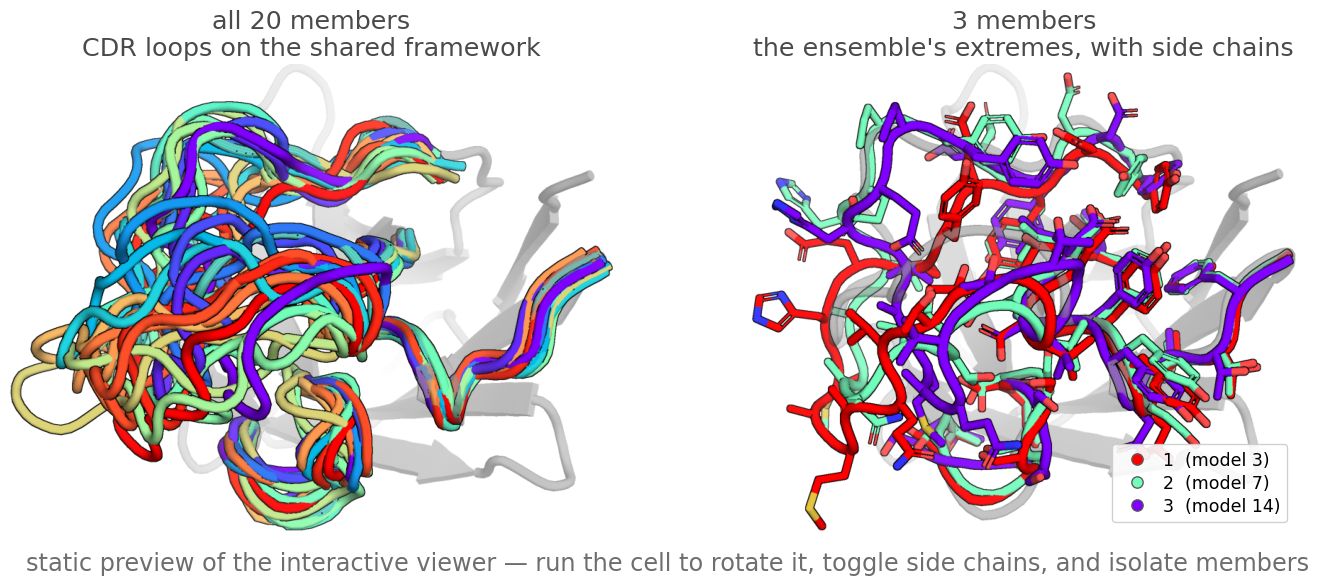

In [5]:
from boltz_cdr.visualize import ensemble_view

view = ensemble_view(
    structures,
    annotation,
    values=selected[COLOR_BY].to_numpy(),
    max_overlay=24,
)
view.show()

### Conformation landscape

The same loops projected to two dimensions by PCA, with `Z_COLUMN` smoothed over the plane
into a surface — read like an energy landscape whose reaction coordinate is loop
conformation. Set it to `dockq` and the difference between the two surfaces is the scorer
question in visual form. The axis labels report how much variance the plane captures, the
honest caveat on any such plot.

Each point is **filled** with its color from the overlay above (run that cell first) and
**ringed** with its value on the surface's own scale.

PC1+PC2 capture 53% of the conformational variance
kernel bandwidth 9.19; 98% of the plane supported
39 CDR residues compared across all members


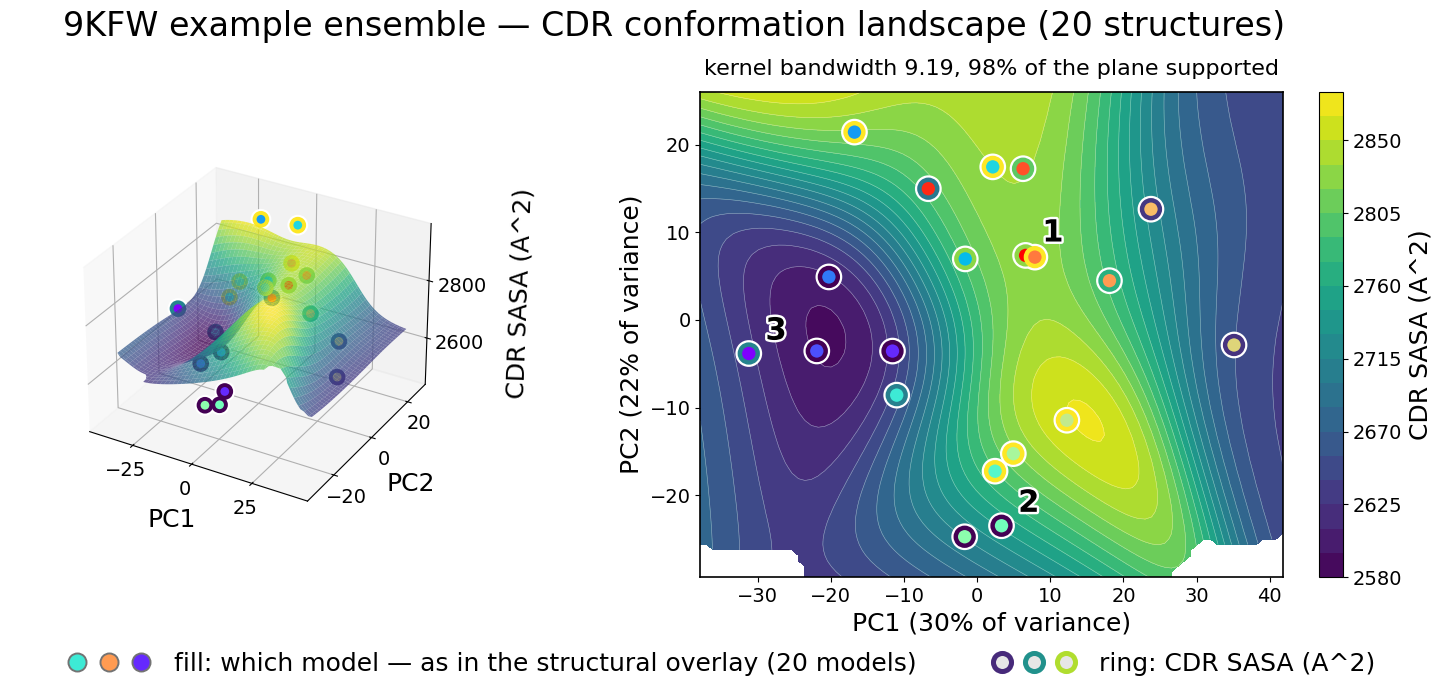

In [6]:
import pathlib
from boltz_cdr.visualize import conformation_landscape, extreme_members, plot_landscape

Z_COLUMN = "conf_iptm"     # try "dockq", "shape_complementarity", "conf_complex_plddt"
if EXAMPLE_ENSEMBLE:
    Z_COLUMN = COLOR_BY    # the example ensemble carries only the one quantity

landscape, projection, coords = conformation_landscape(
    structures,
    annotation,
    selected[Z_COLUMN].to_numpy(),
    method="pca",          # or "mds"
)

# Number the three structures the overlay above singles out — the two most different loop
# conformations and one between them — so a point here can be matched to a loop there.
# Both figures call `extreme_members`, so 1, 2 and 3 mean the same structures in each.
callouts = [""] * len(structures)
for number, index in enumerate(extreme_members(coords), start=1):
    callouts[index] = str(number)

fig, _ = plot_landscape(
    landscape,
    projection,
    value_label=Z_COLUMN,
    title=f"{VIEW_TARGET} — CDR conformation landscape ({len(structures)} structures)",
    labels=callouts,
    # Fill each point with the color its loops have in the overlay above, so a feature here
    # can be traced to a structure there. Only possible when the overlay drew every
    # member — raise `max_overlay` if it thinned the ensemble.
    point_colors=view.colors if len(view.colors) == len(structures) else None,
)
# Saved beside the tables, when there is a results tree to save it into.
if pathlib.Path(RESULTS).exists():
    pathlib.Path(f"{RESULTS}/analysis").mkdir(parents=True, exist_ok=True)
    fig.savefig(f"{RESULTS}/analysis/cdr_landscape.png", bbox_inches="tight")

print(f"PC1+PC2 capture {projection.explained_variance.sum():.0%} of the conformational variance")
print(f"kernel bandwidth {landscape.bandwidth:.2f}; {landscape.coverage:.0%} of the plane supported")
print(f"{len(coords.residue_indices)} CDR residues compared across all members")

## 10 · Figures

Three summary panels straight from the tables: DockQ per arm, ensemble diversity, and
confidence against physics colored by true quality — the scorer-disagreement picture.

In [ ]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

# Print-sized type, so a panel lifted out of this notebook is legible at column width.
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "font.size": 20,
    "axes.titlesize": 20, "axes.labelsize": 20,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "legend.fontsize": 16, "axes.linewidth": 1.2,
})

samples = pd.read_csv(f"{RESULTS}/analysis/samples.csv")
ensembles = pd.read_csv(f"{RESULTS}/analysis/ensembles.csv")
scorers = pd.read_csv(f"{RESULTS}/analysis/scorers.csv")

fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))

# DockQ distribution per arm
arms = sorted(samples["arm"].unique())
axes[0].boxplot([samples.loc[samples.arm == a, "dockq"].dropna() for a in arms], labels=arms)
for threshold, label in ((0.23, "acceptable"), (0.49, "medium"), (0.80, "high")):
    axes[0].axhline(threshold, ls="--", lw=1.2, color="gray")
    axes[0].text(0.55, threshold + 0.012, label, fontsize=14, color="gray")
axes[0].set_ylabel("DockQ"); axes[0].set_title("Accuracy by arm")
axes[0].tick_params(axis="x", rotation=45)

# Diversity vs coverage
for arm in arms:
    row = ensembles[ensembles.arm == arm]
    axes[1].scatter(row["mean_pairwise_cdr3_rmsd"], row["best_dockq"], s=160, label=arm)
axes[1].set_xlabel("mean pairwise CDR3 RMSD (A)  — diversity")
axes[1].set_ylabel("best-of-N DockQ  — coverage")
axes[1].set_title("Does extra diversity buy coverage?")
axes[1].legend()

# Scorer ranking power
top = scorers.head(10).iloc[::-1]
colors = ["tab:blue" if s.startswith("conf") else "tab:orange" for s in top["scorer"]]
axes[2].barh(top["scorer"], top["top1_dockq"], color=colors)
axes[2].axvline(scorers["mean_dockq"].iloc[0], ls="--", lw=1.6, color="gray", label="random pick")
axes[2].axvline(scorers["oracle_dockq"].iloc[0], ls="-", lw=1.6, color="black", label="oracle")
axes[2].set_xlabel("DockQ of the top-1 pick"); axes[2].set_title("Which scorer selects well?")
axes[2].legend(); axes[2].tick_params(axis="y", labelsize=14)

plt.tight_layout()
plt.savefig(f"{RESULTS}/analysis/summary.png", bbox_inches="tight")
plt.show()

In [ ]:
# Confidence vs physics, colored by true quality — the scorer-disagreement picture.
fig, ax = plt.subplots(figsize=(9, 7.5))
sc = ax.scatter(samples["conf_iptm"], samples["shape_complementarity"],
                c=samples["dockq"], cmap="viridis", s=150, edgecolor="k", linewidth=0.7)
ax.set_xlabel("Boltz ipTM  (model confidence)")
ax.set_ylabel("shape complementarity Sc  (physics)")
ax.set_title("Where the two scorer families disagree")
bar = plt.colorbar(sc)
bar.set_label("true DockQ", fontsize=20)
bar.ax.tick_params(labelsize=18)
plt.tight_layout(); plt.show()

## 11 · Save results

**Worth running as soon as section 8 finishes, not only at the very end.** Every predicted
structure is already on disk under `results/<target>/<arm>/structures/`, and `samples.csv`
records the path of each one — but that disk belongs to the Colab VM. A kernel restart keeps
it; the session being recycled does not. `04_evaluate.py` re-runs on a laptop against a saved
tree, so the structures are worth keeping.

In [ ]:
# The tables: a few hundred KB, and enough to redo every figure in this notebook.
!cd {RESULTS} && zip -qr /content/analysis_{JOB_NAME}.zip analysis && du -h /content/analysis_{JOB_NAME}.zip

# The structures too — tens of MB, and the only copy of an hour of GPU time.
!zip -qr /content/results_{JOB_NAME}.zip {RESULTS} && du -h /content/results_{JOB_NAME}.zip

from google.colab import files
files.download(f"/content/analysis_{JOB_NAME}.zip")
files.download(f"/content/results_{JOB_NAME}.zip")

## 12 · Keep a copy on Drive

Copies the whole run into a folder named after `JOB_NAME`. Drive outlives the VM, which a
download to a laptop also does — but this one closes the loop: point `RESULTS` at the copy
in section 3 and a later session reads these predictions instead of making them again,
skipping sections 5 to 7 entirely.

Worth knowing why that matters. A Colab notebook gets its own VM, and `/content` on it is
empty at the start and gone when the session ends — a *new* notebook cannot see the previous
one's `results/` at all. Drive is the only place a run survives both. Section 9 rebases the
structure paths recorded in `samples.csv` onto `RESULTS`, so a tree read from its Drive copy
still resolves; re-running section 8 against the new path rewrites them properly.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pathlib, shutil

DRIVE_DIR = pathlib.Path("/content/drive/MyDrive/boltz-cdr") / JOB_NAME
if (DRIVE_DIR / "results").exists():
    print(f"{DRIVE_DIR}/results already exists — change JOB_NAME to keep both runs.")
else:
    DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    shutil.copytree(RESULTS, DRIVE_DIR / "results")
    print("copied", RESULTS, "->", DRIVE_DIR / "results")

print()
print("To reuse these predictions in a later session, set this in section 3 and run")
print("sections 1-3, then skip to section 8:")
print(f'    RESULTS = "{DRIVE_DIR}/results"')